# Extension: How does digital-simulation accuracy depend on Trotter timestep and hardware noise?

6.1 Timestep convergence: vary \(\Delta t\) in a noiseless circuit and measure how the error changes.

6.2 Verify Trotter error scaling: test whether reducing \(\Delta t\) gives the expected convergence.

6.3 Circuit-depth trade-off: quantify how smaller timesteps increase gate count/depth.

6.4 Add depolarising hardware noise: introduce controllable one- and two-qubit gate errors.

6.5 Noise-strength scan: determine how magnetisation accuracy deteriorates as \(p\) increases.

6.6 Combine both effects: identify the trade-off between Trotter error and hardware noise and produce the final extension result.

6.1 Timestep convergence

Running dt = 0.8 ...
Running dt = 0.4 ...
Running dt = 0.2 ...
Running dt = 0.1 ...

All timestep simulations complete.

TIMESTEP CONVERGENCE
--------------------
      dt    gamma*dt     Steps          RMSE
--------------------------------------------
   0.800       0.400        10      0.054812
   0.400       0.200        20      0.023482
   0.200       0.100        40      0.013787
   0.100       0.050        80      0.012290


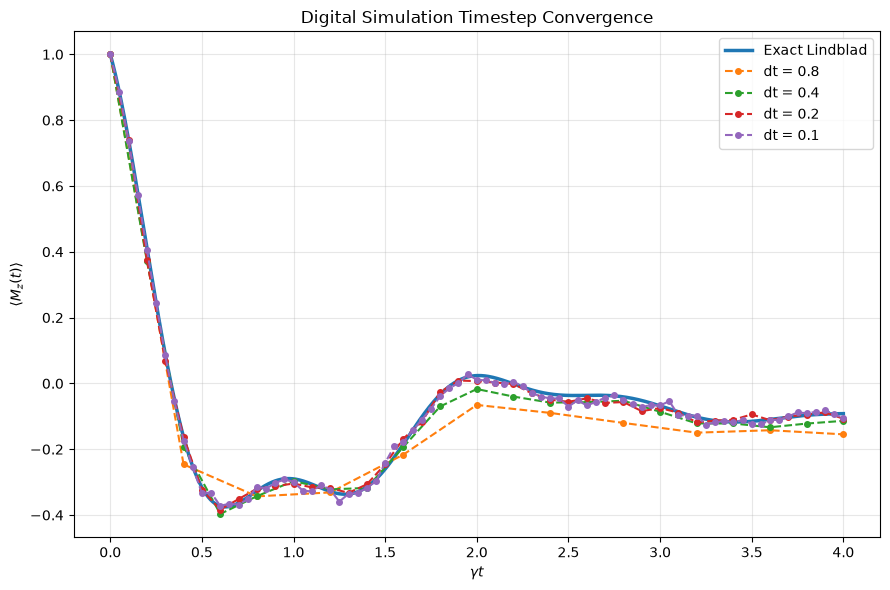

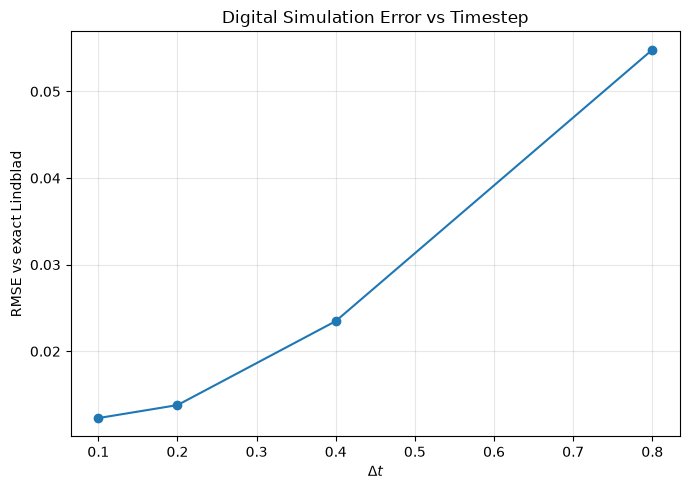


EXERCISE 6.1 SUMMARY
--------------------
Lowest-error timestep = 0.1
Lowest RMSE           = 0.012290

Exercise 6.1 complete.


In [1]:
# Exercise 6.1 — Timestep convergence of the digital simulation

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from scipy.linalg import expm

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


# ------------------------------------------------------------
# 1. Physical parameters
# ------------------------------------------------------------

J = 1.0
Delta = 1.0
gamma = 0.5

# Keep the same physical final time as Notebook 04/05
gamma_t_max = 4.0

t_max = gamma_t_max / gamma

# Fixed ordering parameter from the paper
x_fixed = 0.4906


# ------------------------------------------------------------
# 2. NumPy operators
# ------------------------------------------------------------

I = np.eye(2, dtype=complex)

X = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

Z = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

sigma_minus = np.array([
    [0, 0],
    [1, 0]
], dtype=complex)


X1 = np.kron(X, I)
X2 = np.kron(I, X)

Z1 = np.kron(Z, I)
Z2 = np.kron(I, Z)

ZZ = np.kron(Z, Z)


# ------------------------------------------------------------
# 3. Hamiltonian and collapse operators
# ------------------------------------------------------------

H = (
    -J * ZZ
    + Delta * (X1 + X2)
)

L1 = (
    np.sqrt(gamma)
    * np.kron(sigma_minus, I)
)

L2 = (
    np.sqrt(gamma)
    * np.kron(I, sigma_minus)
)

Mz = (
    Z1 + Z2
) / 2


# ------------------------------------------------------------
# 4. Initial state
#
# |00> = |up up>
# ------------------------------------------------------------

psi0 = np.array(
    [1, 0, 0, 0],
    dtype=complex
)

rho0 = np.outer(
    psi0,
    psi0.conj()
)


# ------------------------------------------------------------
# 5. Exact Lindblad reference
#
# Use a dense grid, then interpolate onto each circuit grid.
# ------------------------------------------------------------

H_qt = qt.Qobj(
    H,
    dims=[[2, 2], [2, 2]]
)

rho0_qt = qt.Qobj(
    rho0,
    dims=[[2, 2], [2, 2]]
)

Mz_qt = qt.Qobj(
    Mz,
    dims=[[2, 2], [2, 2]]
)

collapse_ops_qt = [
    qt.Qobj(
        L,
        dims=[[2, 2], [2, 2]]
    )
    for L in [L1, L2]
]


exact_times = np.linspace(
    0,
    t_max,
    1001
)

exact_result = qt.mesolve(
    H_qt,
    rho0_qt,
    exact_times,
    collapse_ops_qt,
    e_ops=[Mz_qt]
)

Mz_exact_dense = np.real(
    exact_result.expect[0]
)


# ------------------------------------------------------------
# 6. Trotter Hamiltonian helper
# ------------------------------------------------------------

def append_dti_trotter(
    circuit,
    q0,
    q1,
    tau
):
    """
    Symmetric second-order Trotter approximation:
    
    exp(-i H tau)
    
    ≈
    
    exp(-i H_X tau/2)
    exp(-i H_ZZ tau)
    exp(-i H_X tau/2)
    """

    # Half transverse-field evolution
    theta_x = Delta * tau

    circuit.rx(
        theta_x,
        q0
    )

    circuit.rx(
        theta_x,
        q1
    )

    # Full ZZ interaction
    theta_zz = -2 * J * tau

    circuit.rzz(
        theta_zz,
        q0,
        q1
    )

    # Final half transverse-field evolution
    circuit.rx(
        theta_x,
        q0
    )

    circuit.rx(
        theta_x,
        q1
    )


# ------------------------------------------------------------
# 7. Decay-channel helper
# ------------------------------------------------------------

def append_decay_channel(
    circuit,
    system_qubit,
    ancilla_qubit,
    classical_bit,
    dt_local
):

    theta_decay = (
        2
        * np.arcsin(
            np.sqrt(
                gamma * dt_local
            )
        )
    )

    # Control on excited state |0>
    circuit.x(
        system_qubit
    )

    circuit.cry(
        theta_decay,
        system_qubit,
        ancilla_qubit
    )

    circuit.x(
        system_qubit
    )

    # ancilla = 1 causes |0> -> |1>
    circuit.cx(
        ancilla_qubit,
        system_qubit
    )

    circuit.measure(
        ancilla_qubit,
        classical_bit
    )

    circuit.reset(
        ancilla_qubit
    )


# ------------------------------------------------------------
# 8. Build repeated digital simulation
# ------------------------------------------------------------

def build_circuit(
    number_of_steps,
    dt_local
):

    qc = QuantumCircuit(
        3,
        3
    )

    for step in range(
        number_of_steps
    ):

        # Hamiltonian before dissipative part
        append_dti_trotter(
            qc,
            0,
            1,
            x_fixed * dt_local
        )

        # Spin 1 decay
        append_decay_channel(
            qc,
            0,
            2,
            0,
            dt_local
        )

        # Spin 2 decay
        append_decay_channel(
            qc,
            1,
            2,
            0,
            dt_local
        )

        # Remaining Hamiltonian
        append_dti_trotter(
            qc,
            0,
            1,
            (1 - x_fixed) * dt_local
        )


    # Final system measurements
    qc.measure(
        0,
        1
    )

    qc.measure(
        1,
        2
    )

    return qc


# ------------------------------------------------------------
# 9. Magnetisation from measurement counts
# ------------------------------------------------------------

def magnetisation_from_counts(
    counts,
    shots
):

    total = 0.0

    for bitstring, count in counts.items():

        bits = bitstring.replace(
            " ",
            ""
        )

        spin2 = int(
            bits[0]
        )

        spin1 = int(
            bits[1]
        )

        z1 = (
            1
            if spin1 == 0
            else -1
        )

        z2 = (
            1
            if spin2 == 0
            else -1
        )

        mz = (
            z1 + z2
        ) / 2

        total += (
            mz * count
        )

    return (
        total / shots
    )


# ------------------------------------------------------------
# 10. Function to simulate one timestep choice
# ------------------------------------------------------------

simulator = AerSimulator()

shots = 4096


def simulate_dt(
    dt_local
):

    n_steps = int(
        round(
            t_max / dt_local
        )
    )

    times = (
        np.arange(
            n_steps + 1
        )
        * dt_local
    )

    gamma_times = (
        gamma * times
    )


    circuits = [
        build_circuit(
            step,
            dt_local
        )
        for step in range(
            n_steps + 1
        )
    ]


    compiled = transpile(
        circuits,
        simulator,
        optimization_level=1
    )


    result = simulator.run(
        compiled,
        shots=shots
    ).result()


    magnetisation = []


    for i in range(
        len(circuits)
    ):

        counts = result.get_counts(
            i
        )

        magnetisation.append(
            magnetisation_from_counts(
                counts,
                shots
            )
        )


    magnetisation = np.array(
        magnetisation
    )


    # Exact reference on the same time grid
    exact_on_grid = np.interp(
        times,
        exact_times,
        Mz_exact_dense
    )


    rmse = np.sqrt(
        np.mean(
            (
                magnetisation
                - exact_on_grid
            )**2
        )
    )


    return (
        gamma_times,
        magnetisation,
        exact_on_grid,
        rmse,
        n_steps
    )


# ------------------------------------------------------------
# 11. Scan several timesteps
# ------------------------------------------------------------

dt_values = [
    0.8,
    0.4,
    0.2,
    0.1
]

results_dt = {}


for dt_test in dt_values:

    print(
        f"Running dt = {dt_test} ..."
    )

    (
        gamma_times_test,
        mz_test,
        exact_test,
        rmse_test,
        n_steps_test
    ) = simulate_dt(
        dt_test
    )


    results_dt[
        dt_test
    ] = {
        "gamma_times": gamma_times_test,
        "mz": mz_test,
        "exact": exact_test,
        "rmse": rmse_test,
        "steps": n_steps_test
    }


print(
    "\nAll timestep simulations complete."
)


# ------------------------------------------------------------
# 12. Print convergence table
# ------------------------------------------------------------

print(
    "\nTIMESTEP CONVERGENCE"
)

print(
    "--------------------"
)

print(
    f"{'dt':>8}"
    f"{'gamma*dt':>12}"
    f"{'Steps':>10}"
    f"{'RMSE':>14}"
)

print(
    "-" * 44
)


for dt_test in dt_values:

    result = results_dt[
        dt_test
    ]

    print(
        f"{dt_test:>8.3f}"
        f"{gamma * dt_test:>12.3f}"
        f"{result['steps']:>10d}"
        f"{result['rmse']:>14.6f}"
    )


# ------------------------------------------------------------
# 13. Plot dynamics for each timestep
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    gamma * exact_times,
    Mz_exact_dense,
    linewidth=2.5,
    label="Exact Lindblad"
)


for dt_test in dt_values:

    result = results_dt[
        dt_test
    ]

    plt.plot(
        result["gamma_times"],
        result["mz"],
        marker="o",
        linestyle="--",
        markersize=4,
        label=f"dt = {dt_test}"
    )


plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    r"$\langle M_z(t)\rangle$"
)

plt.title(
    "Digital Simulation Timestep Convergence"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 14. Plot RMSE versus timestep
# ------------------------------------------------------------

rmse_values = [
    results_dt[
        dt_test
    ]["rmse"]
    for dt_test in dt_values
]


plt.figure(
    figsize=(7, 5)
)

plt.plot(
    dt_values,
    rmse_values,
    marker="o"
)

plt.xlabel(
    r"$\Delta t$"
)

plt.ylabel(
    "RMSE vs exact Lindblad"
)

plt.title(
    "Digital Simulation Error vs Timestep"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 15. Final summary
# ------------------------------------------------------------

best_dt = min(
    results_dt,
    key=lambda dt:
        results_dt[dt]["rmse"]
)

print(
    "\nEXERCISE 6.1 SUMMARY"
)

print(
    "--------------------"
)

print(
    f"Lowest-error timestep = "
    f"{best_dt}"
)

print(
    f"Lowest RMSE           = "
    f"{results_dt[best_dt]['rmse']:.6f}"
)

print(
    "\nExercise 6.1 complete."
)

6.2 Verify Trotter error scaling: test whether reducing \(\Delta t\) gives the expected convergence.


EXERCISE 6.2 — ERROR SCALING
----------------------------
        dt            RMSE
--------------------------
    0.1000      0.01228966
    0.2000      0.01378747
    0.4000      0.02348229
    0.8000      0.05481212

GLOBAL POWER-LAW FIT
--------------------
RMSE ≈ C * dt^p
C = 0.053915
p = 0.7239

LOCAL CONVERGENCE ORDERS
------------------------
dt 0.100 -> 0.200 : p = 0.1659
dt 0.200 -> 0.400 : p = 0.7682
dt 0.400 -> 0.800 : p = 1.2229

ERROR REDUCTION
---------------
dt 0.100 -> 0.200: error changes by 1.122x
dt 0.200 -> 0.400: error changes by 1.703x
dt 0.400 -> 0.800: error changes by 2.334x


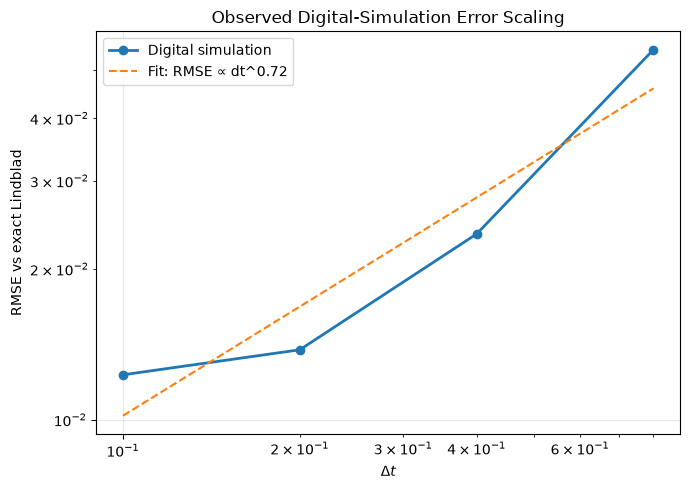

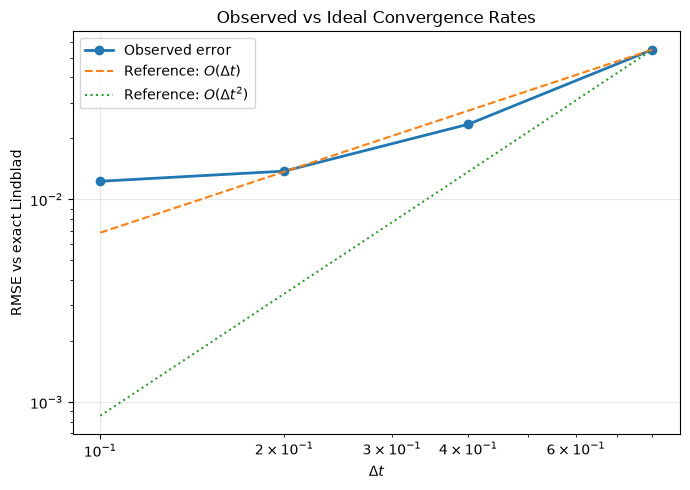


SMALL-dt CHECK
--------------
Smallest dt             = 0.1
RMSE at smallest dt     = 0.012290
Next-smallest dt        = 0.2
RMSE at next-smallest   = 0.013787
Error ratio             = 1.122

EXERCISE 6.2 SUMMARY
--------------------
Observed global exponent p = 0.7239
The observed scaling lies between first- and second-order behaviour.

Exercise 6.2 complete.


In [2]:
# Exercise 6.2 — Estimate the observed convergence order

# Uses from Exercise 6.1:
#
# dt_values
# results_dt


# ------------------------------------------------------------
# 1. Collect timestep and RMSE data
# ------------------------------------------------------------

dt_array = np.array(
    sorted(dt_values),
    dtype=float
)

rmse_array = np.array(
    [
        results_dt[dt]["rmse"]
        for dt in dt_array
    ],
    dtype=float
)


print("EXERCISE 6.2 — ERROR SCALING")
print("----------------------------")

print(
    f"{'dt':>10}"
    f"{'RMSE':>16}"
)

print("-" * 26)

for dt_test, error in zip(
    dt_array,
    rmse_array
):
    print(
        f"{dt_test:>10.4f}"
        f"{error:>16.8f}"
    )


# ------------------------------------------------------------
# 2. Fit the power law
#
# RMSE = C * dt^p
#
# Take logarithms:
#
# log(RMSE) = log(C) + p log(dt)
#
# Therefore p is the slope of the log-log graph.
# ------------------------------------------------------------

log_dt = np.log(
    dt_array
)

log_rmse = np.log(
    rmse_array
)


fit_coefficients = np.polyfit(
    log_dt,
    log_rmse,
    deg=1
)

p_observed = (
    fit_coefficients[0]
)

log_C = (
    fit_coefficients[1]
)

C_observed = np.exp(
    log_C
)


# Predicted errors from fitted power law
rmse_fit = (
    C_observed
    * dt_array**p_observed
)


print("\nGLOBAL POWER-LAW FIT")
print("--------------------")

print(
    f"RMSE ≈ C * dt^p"
)

print(
    f"C = {C_observed:.6f}"
)

print(
    f"p = {p_observed:.4f}"
)


# ------------------------------------------------------------
# 3. Calculate local convergence orders
#
# Between two successive timesteps:
#
# p =
#
# log(E1/E2)
# ----------------
# log(dt1/dt2)
#
# This shows whether the apparent scaling is consistent
# across the timestep range.
# ------------------------------------------------------------

local_orders = []


for i in range(
    len(dt_array) - 1
):

    dt_small = (
        dt_array[i]
    )

    dt_large = (
        dt_array[i + 1]
    )

    error_small = (
        rmse_array[i]
    )

    error_large = (
        rmse_array[i + 1]
    )


    p_local = (
        np.log(
            error_large
            / error_small
        )
        /
        np.log(
            dt_large
            / dt_small
        )
    )


    local_orders.append(
        p_local
    )


print("\nLOCAL CONVERGENCE ORDERS")
print("------------------------")

for i, p_local in enumerate(
    local_orders
):

    print(
        f"dt {dt_array[i]:.3f} -> "
        f"{dt_array[i+1]:.3f} : "
        f"p = {p_local:.4f}"
    )


# ------------------------------------------------------------
# 4. Error reduction factors
# ------------------------------------------------------------

print("\nERROR REDUCTION")
print("---------------")


for i in range(
    len(dt_array) - 1
):

    factor = (
        rmse_array[i + 1]
        / rmse_array[i]
    )

    print(
        f"dt {dt_array[i]:.3f} -> "
        f"{dt_array[i+1]:.3f}: "
        f"error changes by "
        f"{factor:.3f}x"
    )


# ------------------------------------------------------------
# 5. Plot RMSE on log-log axes
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)


plt.loglog(
    dt_array,
    rmse_array,
    marker="o",
    linewidth=2,
    label="Digital simulation"
)


plt.loglog(
    dt_array,
    rmse_fit,
    linestyle="--",
    label=(
        f"Fit: RMSE ∝ dt^{p_observed:.2f}"
    )
)


plt.xlabel(
    r"$\Delta t$"
)

plt.ylabel(
    "RMSE vs exact Lindblad"
)

plt.title(
    "Observed Digital-Simulation Error Scaling"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 6. Compare against ideal first- and second-order scaling
#
# These reference lines are normalised to the largest
# timestep result. They are guides only.
# ------------------------------------------------------------

dt_reference = np.array(
    dt_array
)

anchor_dt = (
    dt_array[-1]
)

anchor_error = (
    rmse_array[-1]
)


first_order_reference = (
    anchor_error
    * (
        dt_reference
        / anchor_dt
    )
)


second_order_reference = (
    anchor_error
    * (
        dt_reference
        / anchor_dt
    )**2
)


plt.figure(
    figsize=(7, 5)
)


plt.loglog(
    dt_array,
    rmse_array,
    marker="o",
    linewidth=2,
    label="Observed error"
)


plt.loglog(
    dt_reference,
    first_order_reference,
    linestyle="--",
    label=r"Reference: $O(\Delta t)$"
)


plt.loglog(
    dt_reference,
    second_order_reference,
    linestyle=":",
    label=r"Reference: $O(\Delta t^2)$"
)


plt.xlabel(
    r"$\Delta t$"
)

plt.ylabel(
    "RMSE vs exact Lindblad"
)

plt.title(
    "Observed vs Ideal Convergence Rates"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 7. Check whether shot noise may be producing an error floor
#
# If the improvement becomes much weaker at the smallest dt,
# finite-shot statistical error may be competing with the
# actual discretisation error.
# ------------------------------------------------------------

smallest_dt = (
    dt_array[0]
)

second_smallest_dt = (
    dt_array[1]
)

smallest_error = (
    rmse_array[0]
)

second_smallest_error = (
    rmse_array[1]
)


small_dt_improvement = (
    second_smallest_error
    / smallest_error
)


print("\nSMALL-dt CHECK")
print("--------------")

print(
    f"Smallest dt             = "
    f"{smallest_dt}"
)

print(
    f"RMSE at smallest dt     = "
    f"{smallest_error:.6f}"
)

print(
    f"Next-smallest dt        = "
    f"{second_smallest_dt}"
)

print(
    f"RMSE at next-smallest   = "
    f"{second_smallest_error:.6f}"
)

print(
    f"Error ratio             = "
    f"{small_dt_improvement:.3f}"
)


# ------------------------------------------------------------
# 8. Final interpretation
# ------------------------------------------------------------

print("\nEXERCISE 6.2 SUMMARY")
print("--------------------")

print(
    f"Observed global exponent p = "
    f"{p_observed:.4f}"
)


if p_observed > 1.7:

    interpretation = (
        "The observed scaling is close to second-order."
    )

elif p_observed > 0.7:

    interpretation = (
        "The observed scaling lies between first- and "
        "second-order behaviour."
    )

elif p_observed > 0:

    interpretation = (
        "The error decreases with timestep, but more "
        "slowly than ideal first-order scaling."
    )

else:

    interpretation = (
        "The current data do not show clean timestep "
        "convergence; sampling noise or another error "
        "source may be dominating."
    )


print(
    interpretation
)

print(
    "\nExercise 6.2 complete."
)

6.3 Circuit-depth trade-off: quantify how smaller timesteps increase gate count/depth.


EXERCISE 6.3 — CIRCUIT RESOURCE SCALING
---------------------------------------
      dt   Steps     Depth   Total Ops    1Q Gates    CX Gates
--------------------------------------------------------------
   0.100      80      3446        5132        4010         800
   0.200      40      1726        2572        2010         400
   0.400      20       866        1292        1010         200
   0.800      10       436         652         510         100


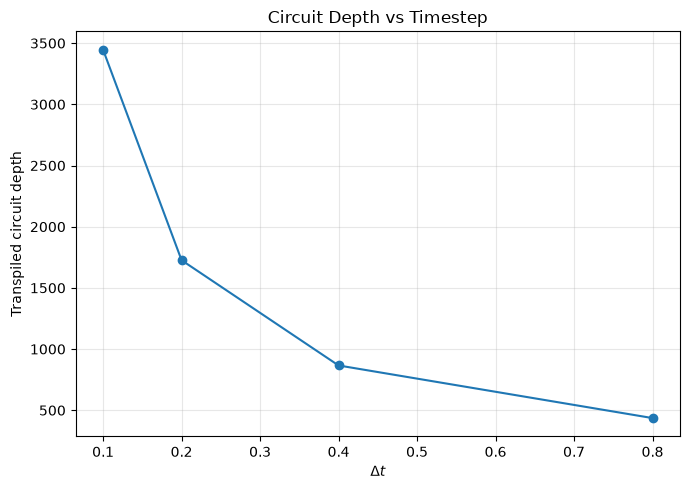

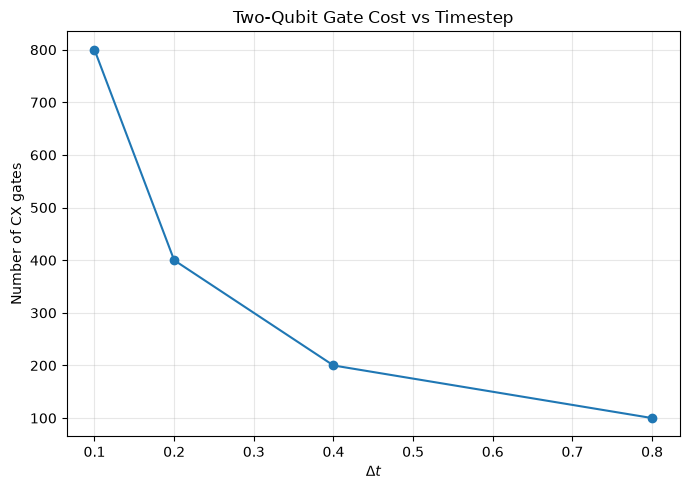


RESOURCE SCALING FITS
----------------------
Depth ≈ 344.000 * (1/dt) + 6.000
CX count ≈ 80.000 * (1/dt) + -0.000


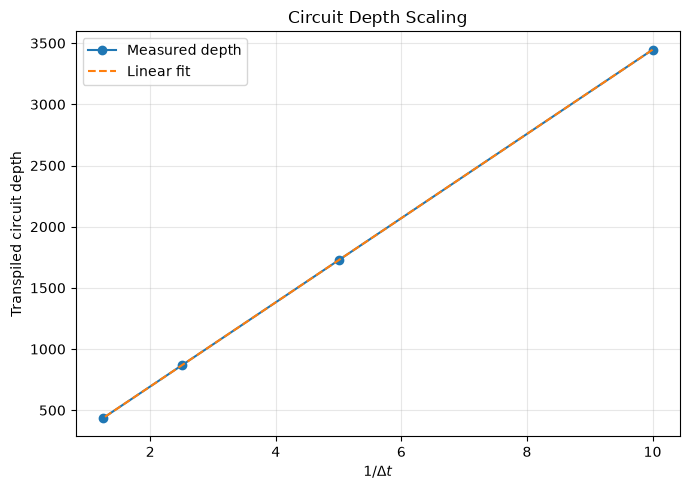


ACCURACY–DEPTH TRADE-OFF
------------------------
      dt          RMSE       Depth        CX
--------------------------------------------
   0.100      0.012290        3446       800
   0.200      0.013787        1726       400
   0.400      0.023482         866       200
   0.800      0.054812         436       100


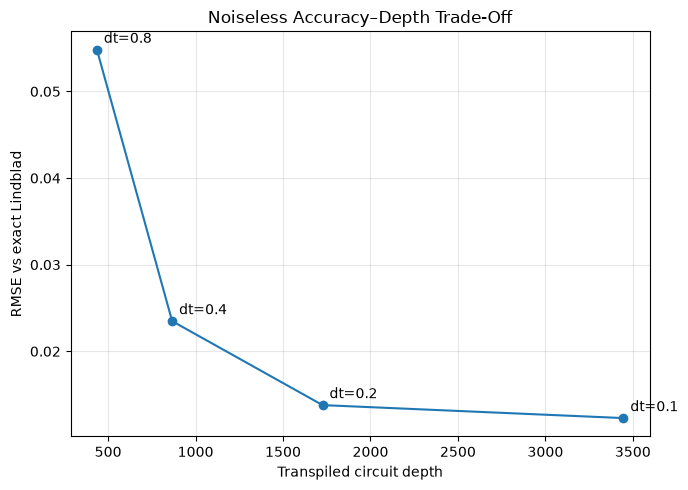


EXERCISE 6.3 SUMMARY
--------------------
Largest timestep       = 0.8
Smallest timestep      = 0.1
Depth increase         = 7.90x
CX-gate increase       = 8.00x

Exercise 6.3 complete.


In [3]:
# Exercise 6.3 — Circuit depth and gate-count scaling

# Uses from Exercise 6.1:
#
# dt_values
# t_max
# build_circuit()


# ------------------------------------------------------------
# 1. Hardware-like basis gate set
#
# We decompose higher-level gates such as RZZ and CRY into
# a more elementary basis so that the two-qubit cost is visible.
# ------------------------------------------------------------

basis_gates = [
    "rz",
    "sx",
    "x",
    "cx",
    "reset",
    "measure"
]


# ------------------------------------------------------------
# 2. Collect circuit-resource statistics
# ------------------------------------------------------------

resource_results = {}


for dt_test in sorted(dt_values):

    n_steps = int(
        round(
            t_max / dt_test
        )
    )


    # Build the circuit that evolves all the way to t_max
    qc = build_circuit(
        number_of_steps=n_steps,
        dt_local=dt_test
    )


    # Logical circuit before decomposition
    logical_depth = (
        qc.depth()
    )

    logical_size = (
        qc.size()
    )


    # --------------------------------------------------------
    # Transpile to elementary gate basis
    # --------------------------------------------------------

    compiled = transpile(
        qc,
        basis_gates=basis_gates,
        optimization_level=1
    )


    # --------------------------------------------------------
    # Gate counts
    # --------------------------------------------------------

    counts = compiled.count_ops()


    n_cx = int(
        counts.get(
            "cx",
            0
        )
    )

    n_rz = int(
        counts.get(
            "rz",
            0
        )
    )

    n_sx = int(
        counts.get(
            "sx",
            0
        )
    )

    n_x = int(
        counts.get(
            "x",
            0
        )
    )

    n_reset = int(
        counts.get(
            "reset",
            0
        )
    )

    n_measure = int(
        counts.get(
            "measure",
            0
        )
    )


    # One-qubit gates in this chosen basis
    n_1q = (
        n_rz
        + n_sx
        + n_x
    )


    resource_results[
        dt_test
    ] = {
        "steps": n_steps,

        "logical_depth":
            logical_depth,

        "logical_size":
            logical_size,

        "transpiled_depth":
            compiled.depth(),

        "transpiled_size":
            compiled.size(),

        "one_qubit_gates":
            n_1q,

        "cx_gates":
            n_cx,

        "resets":
            n_reset,

        "measurements":
            n_measure
    }


# ------------------------------------------------------------
# 3. Print resource table
# ------------------------------------------------------------

print(
    "EXERCISE 6.3 — CIRCUIT RESOURCE SCALING"
)

print(
    "---------------------------------------"
)


print(
    f"{'dt':>8}"
    f"{'Steps':>8}"
    f"{'Depth':>10}"
    f"{'Total Ops':>12}"
    f"{'1Q Gates':>12}"
    f"{'CX Gates':>12}"
)

print(
    "-" * 62
)


for dt_test in sorted(
    resource_results
):

    r = resource_results[
        dt_test
    ]

    print(
        f"{dt_test:>8.3f}"
        f"{r['steps']:>8d}"
        f"{r['transpiled_depth']:>10d}"
        f"{r['transpiled_size']:>12d}"
        f"{r['one_qubit_gates']:>12d}"
        f"{r['cx_gates']:>12d}"
    )


# ------------------------------------------------------------
# 4. Convert results to arrays for plotting
# ------------------------------------------------------------

dt_resource = np.array(
    sorted(
        resource_results
    ),
    dtype=float
)


steps_array = np.array(
    [
        resource_results[dt]["steps"]
        for dt in dt_resource
    ]
)


depth_array = np.array(
    [
        resource_results[dt][
            "transpiled_depth"
        ]
        for dt in dt_resource
    ]
)


size_array = np.array(
    [
        resource_results[dt][
            "transpiled_size"
        ]
        for dt in dt_resource
    ]
)


cx_array = np.array(
    [
        resource_results[dt][
            "cx_gates"
        ]
        for dt in dt_resource
    ]
)


oneq_array = np.array(
    [
        resource_results[dt][
            "one_qubit_gates"
        ]
        for dt in dt_resource
    ]
)


# ------------------------------------------------------------
# 5. Plot circuit depth versus timestep
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    dt_resource,
    depth_array,
    marker="o"
)

plt.xlabel(
    r"$\Delta t$"
)

plt.ylabel(
    "Transpiled circuit depth"
)

plt.title(
    "Circuit Depth vs Timestep"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 6. Plot CX count versus timestep
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    dt_resource,
    cx_array,
    marker="o"
)

plt.xlabel(
    r"$\Delta t$"
)

plt.ylabel(
    "Number of CX gates"
)

plt.title(
    "Two-Qubit Gate Cost vs Timestep"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 7. Check expected inverse-timestep scaling
#
# For a fixed final physical time:
#
# number of steps ~ 1 / dt
#
# Circuit depth should therefore also grow approximately
# linearly with 1 / dt.
# ------------------------------------------------------------

inverse_dt = (
    1.0 / dt_resource
)


depth_fit = np.polyfit(
    inverse_dt,
    depth_array,
    deg=1
)


cx_fit = np.polyfit(
    inverse_dt,
    cx_array,
    deg=1
)


depth_slope = (
    depth_fit[0]
)

depth_intercept = (
    depth_fit[1]
)


cx_slope = (
    cx_fit[0]
)

cx_intercept = (
    cx_fit[1]
)


print(
    "\nRESOURCE SCALING FITS"
)

print(
    "----------------------"
)

print(
    "Depth ≈ "
    f"{depth_slope:.3f} * (1/dt) "
    f"+ {depth_intercept:.3f}"
)

print(
    "CX count ≈ "
    f"{cx_slope:.3f} * (1/dt) "
    f"+ {cx_intercept:.3f}"
)


# ------------------------------------------------------------
# 8. Plot depth against inverse timestep
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)


plt.plot(
    inverse_dt,
    depth_array,
    marker="o",
    label="Measured depth"
)


plt.plot(
    inverse_dt,
    (
        depth_slope
        * inverse_dt
        + depth_intercept
    ),
    linestyle="--",
    label="Linear fit"
)


plt.xlabel(
    r"$1/\Delta t$"
)

plt.ylabel(
    "Transpiled circuit depth"
)

plt.title(
    "Circuit Depth Scaling"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 9. Combine accuracy and resource cost
#
# Bring in RMSE results from Exercise 6.1.
# ------------------------------------------------------------

print(
    "\nACCURACY–DEPTH TRADE-OFF"
)

print(
    "------------------------"
)


print(
    f"{'dt':>8}"
    f"{'RMSE':>14}"
    f"{'Depth':>12}"
    f"{'CX':>10}"
)

print(
    "-" * 44
)


for dt_test in dt_resource:

    rmse = results_dt[
        dt_test
    ]["rmse"]

    depth = resource_results[
        dt_test
    ]["transpiled_depth"]

    cx = resource_results[
        dt_test
    ]["cx_gates"]


    print(
        f"{dt_test:>8.3f}"
        f"{rmse:>14.6f}"
        f"{depth:>12d}"
        f"{cx:>10d}"
    )


# ------------------------------------------------------------
# 10. Plot accuracy versus circuit depth
# ------------------------------------------------------------

rmse_resource = np.array(
    [
        results_dt[dt]["rmse"]
        for dt in dt_resource
    ]
)


plt.figure(
    figsize=(7, 5)
)


plt.plot(
    depth_array,
    rmse_resource,
    marker="o"
)


for depth, error, dt_test in zip(
    depth_array,
    rmse_resource,
    dt_resource
):

    plt.annotate(
        f"dt={dt_test}",
        (
            depth,
            error
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )


plt.xlabel(
    "Transpiled circuit depth"
)

plt.ylabel(
    "RMSE vs exact Lindblad"
)

plt.title(
    "Noiseless Accuracy–Depth Trade-Off"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 11. Final summary
# ------------------------------------------------------------

smallest_dt = min(
    resource_results
)

largest_dt = max(
    resource_results
)


depth_ratio = (
    resource_results[
        smallest_dt
    ]["transpiled_depth"]
    /
    resource_results[
        largest_dt
    ]["transpiled_depth"]
)


cx_ratio = (
    resource_results[
        smallest_dt
    ]["cx_gates"]
    /
    resource_results[
        largest_dt
    ]["cx_gates"]
)


print(
    "\nEXERCISE 6.3 SUMMARY"
)

print(
    "--------------------"
)

print(
    f"Largest timestep       = "
    f"{largest_dt}"
)

print(
    f"Smallest timestep      = "
    f"{smallest_dt}"
)

print(
    f"Depth increase         = "
    f"{depth_ratio:.2f}x"
)

print(
    f"CX-gate increase       = "
    f"{cx_ratio:.2f}x"
)

print(
    "\nExercise 6.3 complete."
)

6.4 Add depolarising hardware noise: introduce controllable one- and two-qubit gate errors.


EXERCISE 6.4 — DEPOLARISING NOISE
---------------------------------
Two-qubit error p      = 0.03
One-qubit error p/10   = 0.003

Noise model:
NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx', 'x']
  Instructions with noise: ['sx', 'cx', 'x', 'rz']
  All-qubits errors: ['x', 'sx', 'rz', 'cx']


c:\Users\HP\OneDrive\Documents\coding_project\kim-open-quantum-reproduction\.venv\Lib\site-packages\qiskit\transpiler\preset_passmanagers\generate_preset_pass_manager.py:242: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  common_options = _parse_common_options(



Running noisy simulation...
Noisy simulation complete.

NOISE COMPARISON
----------------
Noiseless RMSE       = 0.023482
Noisy RMSE           = 0.107519
Additional RMSE      = 0.084037

MAGNETISATION VALUES
--------------------
   gamma*t       Exact     Noiseless       Noisy
------------------------------------------------
      0.00    1.000000      1.000000    1.000000
      0.20    0.411105      0.371338    0.270020
      0.40   -0.163007     -0.192139   -0.142700
      0.60   -0.372856     -0.396729   -0.253906
      0.80   -0.326517     -0.342773   -0.200317
      1.00   -0.290099     -0.296875   -0.166748
      1.20   -0.328532     -0.322021   -0.180664
      1.40   -0.314468     -0.317627   -0.175415
      1.60   -0.183450     -0.192627   -0.161377
      1.80   -0.033739     -0.070068   -0.157349
      2.00    0.023750     -0.017090   -0.161499
      2.20   -0.001424     -0.040039   -0.157837
      2.40   -0.032090     -0.058350   -0.139282
      2.60   -0.036275     -0.05712

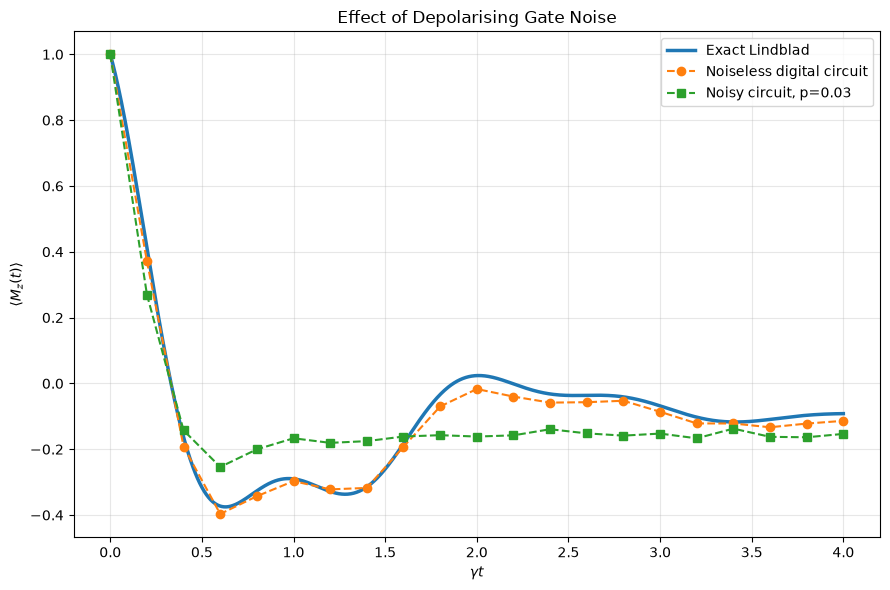

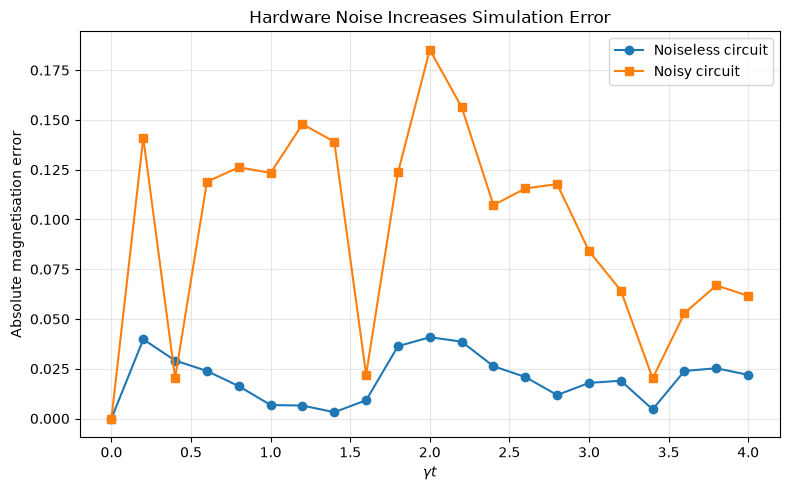


LONG-TIME BEHAVIOUR
-------------------
Exact final <Mz>      = -0.091839
Noiseless final <Mz>  = -0.113770
Noisy final <Mz>      = -0.153442

EXERCISE 6.4 SUMMARY
--------------------
Two-qubit error p       : 0.03
One-qubit error         : 0.003
Noiseless RMSE          : 0.023482
Noisy RMSE              : 0.107519
Noise-induced increase  : 0.084037

Exercise 6.4 complete.


In [4]:
# Exercise 6.4 — Add depolarising gate noise

from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error
)


# ------------------------------------------------------------
# 1. Noise parameters
#
# Paper convention:
#
# two-qubit error = p
# one-qubit error = p / 10
# ------------------------------------------------------------

p_two_qubit = 0.03

p_one_qubit = (
    p_two_qubit / 10
)


# ------------------------------------------------------------
# 2. Build depolarising errors
# ------------------------------------------------------------

error_1q = depolarizing_error(
    p_one_qubit,
    1
)

error_2q = depolarizing_error(
    p_two_qubit,
    2
)


# ------------------------------------------------------------
# 3. Construct noise model
# ------------------------------------------------------------

noise_model = NoiseModel()


# Apply the one-qubit error to the elementary
# one-qubit gates used after transpilation.
noise_model.add_all_qubit_quantum_error(
    error_1q,
    [
        "x",
        "sx",
        "rz"
    ]
)


# Apply the larger two-qubit error to CX gates.
noise_model.add_all_qubit_quantum_error(
    error_2q,
    [
        "cx"
    ]
)


print("EXERCISE 6.4 — DEPOLARISING NOISE")
print("---------------------------------")

print(
    f"Two-qubit error p      = "
    f"{p_two_qubit}"
)

print(
    f"One-qubit error p/10   = "
    f"{p_one_qubit}"
)

print(
    "\nNoise model:"
)

print(
    noise_model
)


# ------------------------------------------------------------
# 4. Create noisy Aer simulator
# ------------------------------------------------------------

noisy_simulator = AerSimulator(
    noise_model=noise_model
)


# ------------------------------------------------------------
# 5. Use original timestep from the paper reproduction
# ------------------------------------------------------------

dt_noise = 0.4

n_steps_noise = int(
    round(
        t_max / dt_noise
    )
)


times_noise = (
    np.arange(
        n_steps_noise + 1
    )
    * dt_noise
)

gamma_times_noise = (
    gamma
    * times_noise
)


# ------------------------------------------------------------
# 6. Build circuits at every time point
# ------------------------------------------------------------

circuits_noise = [
    build_circuit(
        number_of_steps=n,
        dt_local=dt_noise
    )
    for n in range(
        n_steps_noise + 1
    )
]


# ------------------------------------------------------------
# 7. Transpile to the same elementary basis used
#    in Exercise 6.3
# ------------------------------------------------------------

basis_gates_noise = [
    "rz",
    "sx",
    "x",
    "cx",
    "reset",
    "measure"
]


compiled_noise = transpile(
    circuits_noise,
    noisy_simulator,
    basis_gates=basis_gates_noise,
    optimization_level=1
)


# ------------------------------------------------------------
# 8. Run noisy simulation
#
# Paper used 8192 shots per data point.
# ------------------------------------------------------------

shots_noise = 8192


print(
    "\nRunning noisy simulation..."
)


job_noise = noisy_simulator.run(
    compiled_noise,
    shots=shots_noise
)

result_noise = job_noise.result()


print(
    "Noisy simulation complete."
)


# ------------------------------------------------------------
# 9. Extract noisy magnetisation
# ------------------------------------------------------------

Mz_noisy = []


for i in range(
    len(circuits_noise)
):

    counts = result_noise.get_counts(
        i
    )

    mz = magnetisation_from_counts(
        counts,
        shots_noise
    )

    Mz_noisy.append(
        mz
    )


Mz_noisy = np.array(
    Mz_noisy
)


# ------------------------------------------------------------
# 10. Exact Lindblad result on the same grid
# ------------------------------------------------------------

Mz_exact_noise_grid = np.interp(
    times_noise,
    exact_times,
    Mz_exact_dense
)


# ------------------------------------------------------------
# 11. Noiseless digital result for dt = 0.4
#
# Reuse Exercise 6.1 result.
# ------------------------------------------------------------

Mz_noiseless_dt04 = (
    results_dt[
        0.4
    ]["mz"]
)


# ------------------------------------------------------------
# 12. Error metrics
# ------------------------------------------------------------

rmse_noisy = np.sqrt(
    np.mean(
        (
            Mz_noisy
            - Mz_exact_noise_grid
        )**2
    )
)


rmse_noiseless = np.sqrt(
    np.mean(
        (
            Mz_noiseless_dt04
            - Mz_exact_noise_grid
        )**2
    )
)


noise_penalty = (
    rmse_noisy
    - rmse_noiseless
)


# ------------------------------------------------------------
# 13. Print numerical comparison
# ------------------------------------------------------------

print(
    "\nNOISE COMPARISON"
)

print(
    "----------------"
)

print(
    f"Noiseless RMSE       = "
    f"{rmse_noiseless:.6f}"
)

print(
    f"Noisy RMSE           = "
    f"{rmse_noisy:.6f}"
)

print(
    f"Additional RMSE      = "
    f"{noise_penalty:.6f}"
)


# ------------------------------------------------------------
# 14. Show selected time points
# ------------------------------------------------------------

print(
    "\nMAGNETISATION VALUES"
)

print(
    "--------------------"
)

print(
    f"{'gamma*t':>10}"
    f"{'Exact':>12}"
    f"{'Noiseless':>14}"
    f"{'Noisy':>12}"
)

print(
    "-" * 48
)


for t, exact, clean, noisy in zip(
    gamma_times_noise,
    Mz_exact_noise_grid,
    Mz_noiseless_dt04,
    Mz_noisy
):

    print(
        f"{t:>10.2f}"
        f"{exact:>12.6f}"
        f"{clean:>14.6f}"
        f"{noisy:>12.6f}"
    )


# ------------------------------------------------------------
# 15. Plot noisy vs noiseless dynamics
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    gamma * exact_times,
    Mz_exact_dense,
    linewidth=2.5,
    label="Exact Lindblad"
)


plt.plot(
    gamma_times_noise,
    Mz_noiseless_dt04,
    marker="o",
    linestyle="--",
    label="Noiseless digital circuit"
)


plt.plot(
    gamma_times_noise,
    Mz_noisy,
    marker="s",
    linestyle="--",
    label=(
        f"Noisy circuit, p={p_two_qubit}"
    )
)


plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    r"$\langle M_z(t)\rangle$"
)

plt.title(
    "Effect of Depolarising Gate Noise"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 16. Absolute-error comparison
# ------------------------------------------------------------

error_noiseless = np.abs(
    Mz_noiseless_dt04
    - Mz_exact_noise_grid
)

error_noisy = np.abs(
    Mz_noisy
    - Mz_exact_noise_grid
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(
    gamma_times_noise,
    error_noiseless,
    marker="o",
    label="Noiseless circuit"
)


plt.plot(
    gamma_times_noise,
    error_noisy,
    marker="s",
    label="Noisy circuit"
)


plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    "Absolute magnetisation error"
)

plt.title(
    "Hardware Noise Increases Simulation Error"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 17. Long-time behaviour
# ------------------------------------------------------------

print(
    "\nLONG-TIME BEHAVIOUR"
)

print(
    "-------------------"
)

print(
    f"Exact final <Mz>      = "
    f"{Mz_exact_noise_grid[-1]:.6f}"
)

print(
    f"Noiseless final <Mz>  = "
    f"{Mz_noiseless_dt04[-1]:.6f}"
)

print(
    f"Noisy final <Mz>      = "
    f"{Mz_noisy[-1]:.6f}"
)


# ------------------------------------------------------------
# 18. Final summary
# ------------------------------------------------------------

print(
    "\nEXERCISE 6.4 SUMMARY"
)

print(
    "--------------------"
)

print(
    f"Two-qubit error p       : "
    f"{p_two_qubit}"
)

print(
    f"One-qubit error         : "
    f"{p_one_qubit}"
)

print(
    f"Noiseless RMSE          : "
    f"{rmse_noiseless:.6f}"
)

print(
    f"Noisy RMSE              : "
    f"{rmse_noisy:.6f}"
)

print(
    f"Noise-induced increase  : "
    f"{noise_penalty:.6f}"
)

print(
    "\nExercise 6.4 complete."
)

6.5 Noise-strength scan: determine how magnetisation accuracy deteriorates as \(p\) increases.

Running p = 0 ...
Running p = 0.0001 ...
Running p = 0.001 ...
Running p = 0.01 ...
Running p = 0.03 ...

Noise scan complete.

EXERCISE 6.5 — NOISE STRENGTH SCAN
----------------------------------
      p (2Q)     p/10 (1Q)          RMSE      Final <Mz>
--------------------------------------------------------
     0.00000       0.00000      0.021266       -0.114014
     0.00010       0.00001      0.026580       -0.101318
     0.00100       0.00010      0.029606       -0.100830
     0.01000       0.00100      0.070454       -0.135254
     0.03000       0.00300      0.105420       -0.180176


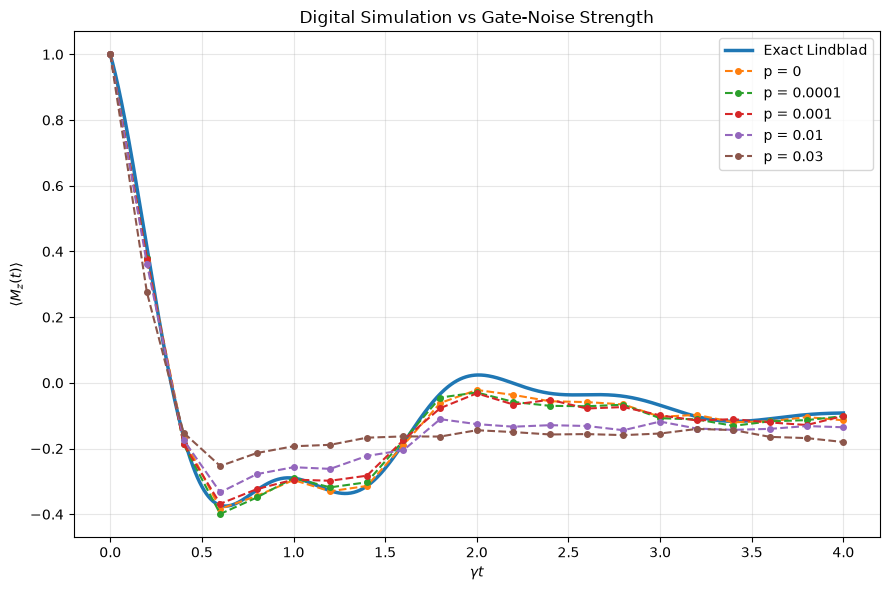

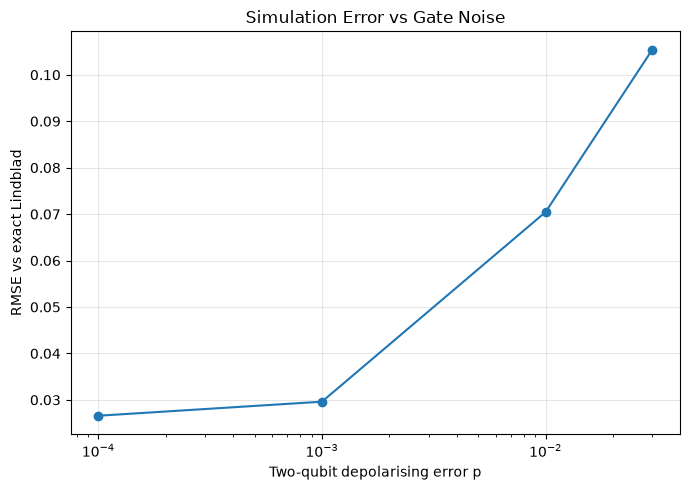


ERROR INCREASE RELATIVE TO p = 0
--------------------------------
p = 0.0001  : +0.005314 RMSE (25.0%)
p = 0.001   : +0.008340 RMSE (39.2%)
p = 0.01    : +0.049188 RMSE (231.3%)
p = 0.03    : +0.084153 RMSE (395.7%)

PAPER-RELEVANT COMPARISON
-------------------------
RMSE at p = 1e-3 : 0.029606
RMSE at p = 3e-2 : 0.105420

EARLY vs LATE-TIME ERROR
------------------------
p = 0       | early = 0.011136 | late = 0.021131
p = 0.0001  | early = 0.014667 | late = 0.027647
p = 0.001   | early = 0.018348 | late = 0.028678
p = 0.01    | early = 0.043853 | late = 0.072525
p = 0.03    | early = 0.091416 | late = 0.094985


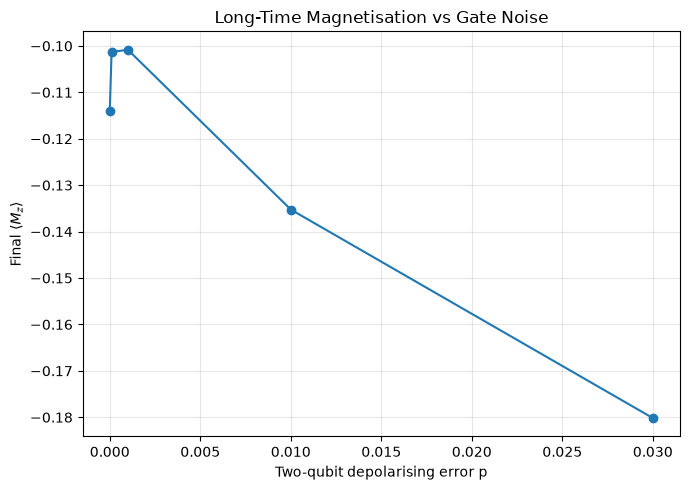


EXERCISE 6.5 SUMMARY
--------------------
Lowest-RMSE noise level = 0
Lowest RMSE             = 0.021266
Highest-RMSE noise level = 0.03
Highest RMSE             = 0.105420

Exercise 6.5 complete.


In [5]:
# Exercise 6.5 — Scan depolarising noise strength

from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error
)


# ------------------------------------------------------------
# 1. Noise strengths to investigate
#
# p = two-qubit depolarising error
#
# one-qubit error = p / 10
# ------------------------------------------------------------

p_values = [
    0.0,
    1e-4,
    1e-3,
    1e-2,
    3e-2
]


# ------------------------------------------------------------
# 2. Keep timestep fixed
# ------------------------------------------------------------

dt_scan = 0.4

n_steps_scan = int(
    round(
        t_max / dt_scan
    )
)

times_scan = (
    np.arange(
        n_steps_scan + 1
    )
    * dt_scan
)

gamma_times_scan = (
    gamma * times_scan
)


# ------------------------------------------------------------
# 3. Exact Lindblad reference on this grid
# ------------------------------------------------------------

Mz_exact_scan = np.interp(
    times_scan,
    exact_times,
    Mz_exact_dense
)


# ------------------------------------------------------------
# 4. Build circuits once
#
# Same physical circuits are used for every noise level.
# ------------------------------------------------------------

circuits_scan = [
    build_circuit(
        number_of_steps=n,
        dt_local=dt_scan
    )
    for n in range(
        n_steps_scan + 1
    )
]


# ------------------------------------------------------------
# 5. Transpile once to elementary basis
# ------------------------------------------------------------

basis_gates_scan = [
    "rz",
    "sx",
    "x",
    "cx",
    "reset",
    "measure"
]


ideal_backend = AerSimulator()


compiled_scan = transpile(
    circuits_scan,
    ideal_backend,
    basis_gates=basis_gates_scan,
    optimization_level=1
)


# ------------------------------------------------------------
# 6. Helper: construct paper-style noise model
# ------------------------------------------------------------

def create_depolarising_noise_model(
    p_two
):
    """
    Paper-style simplified gate noise:

    two-qubit error = p
    one-qubit error = p/10
    """

    noise_model = NoiseModel()

    if p_two == 0:
        return noise_model


    p_one = (
        p_two / 10
    )


    error_1q = depolarizing_error(
        p_one,
        1
    )

    error_2q = depolarizing_error(
        p_two,
        2
    )


    noise_model.add_all_qubit_quantum_error(
        error_1q,
        [
            "x",
            "sx",
            "rz"
        ]
    )


    noise_model.add_all_qubit_quantum_error(
        error_2q,
        [
            "cx"
        ]
    )


    return noise_model


# ------------------------------------------------------------
# 7. Helper: calculate RMSE
# ------------------------------------------------------------

def calculate_rmse(
    approximate,
    exact
):

    return np.sqrt(
        np.mean(
            (
                approximate
                - exact
            )**2
        )
    )


# ------------------------------------------------------------
# 8. Run noise scan
# ------------------------------------------------------------

shots_scan = 4096

noise_results = {}


for p in p_values:

    print(
        f"Running p = {p:.4g} ..."
    )


    noise_model_p = (
        create_depolarising_noise_model(
            p
        )
    )


    simulator_p = AerSimulator(
        noise_model=noise_model_p
    )


    result_p = simulator_p.run(
        compiled_scan,
        shots=shots_scan
    ).result()


    mz_values = []


    for i in range(
        len(compiled_scan)
    ):

        counts = result_p.get_counts(
            i
        )

        mz = magnetisation_from_counts(
            counts,
            shots_scan
        )

        mz_values.append(
            mz
        )


    mz_values = np.array(
        mz_values
    )


    rmse = calculate_rmse(
        mz_values,
        Mz_exact_scan
    )


    noise_results[p] = {
        "mz": mz_values,
        "rmse": rmse
    }


print(
    "\nNoise scan complete."
)


# ------------------------------------------------------------
# 9. Print RMSE table
# ------------------------------------------------------------

print(
    "\nEXERCISE 6.5 — NOISE STRENGTH SCAN"
)

print(
    "----------------------------------"
)


print(
    f"{'p (2Q)':>12}"
    f"{'p/10 (1Q)':>14}"
    f"{'RMSE':>14}"
    f"{'Final <Mz>':>16}"
)

print(
    "-" * 56
)


for p in p_values:

    rmse = noise_results[
        p
    ]["rmse"]

    final_mz = noise_results[
        p
    ]["mz"][-1]


    print(
        f"{p:>12.5f}"
        f"{p/10:>14.5f}"
        f"{rmse:>14.6f}"
        f"{final_mz:>16.6f}"
    )


# ------------------------------------------------------------
# 10. Plot dynamics for all noise levels
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    gamma * exact_times,
    Mz_exact_dense,
    linewidth=2.5,
    label="Exact Lindblad"
)


for p in p_values:

    plt.plot(
        gamma_times_scan,
        noise_results[p]["mz"],
        marker="o",
        linestyle="--",
        markersize=4,
        label=f"p = {p:g}"
    )


plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    r"$\langle M_z(t)\rangle$"
)

plt.title(
    "Digital Simulation vs Gate-Noise Strength"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 11. Plot RMSE versus noise strength
#
# Exclude p=0 from logarithmic x-axis.
# ------------------------------------------------------------

p_nonzero = np.array(
    [
        p
        for p in p_values
        if p > 0
    ]
)


rmse_nonzero = np.array(
    [
        noise_results[p]["rmse"]
        for p in p_nonzero
    ]
)


plt.figure(
    figsize=(7, 5)
)


plt.semilogx(
    p_nonzero,
    rmse_nonzero,
    marker="o"
)


plt.xlabel(
    "Two-qubit depolarising error p"
)

plt.ylabel(
    "RMSE vs exact Lindblad"
)

plt.title(
    "Simulation Error vs Gate Noise"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 12. Calculate degradation relative to noiseless circuit
# ------------------------------------------------------------

rmse_zero = noise_results[
    0.0
]["rmse"]


print(
    "\nERROR INCREASE RELATIVE TO p = 0"
)

print(
    "--------------------------------"
)


for p in p_values[1:]:

    rmse = noise_results[
        p
    ]["rmse"]


    increase = (
        rmse
        - rmse_zero
    )


    percentage = (
        increase
        / rmse_zero
        * 100
    )


    print(
        f"p = {p:<7g} : "
        f"+{increase:.6f} RMSE "
        f"({percentage:.1f}%)"
    )


# ------------------------------------------------------------
# 13. Compare p = 1e-3 and p = 3e-2
#
# These are particularly relevant to the discussion in
# the paper.
# ------------------------------------------------------------

rmse_1e3 = noise_results[
    1e-3
]["rmse"]

rmse_3e2 = noise_results[
    3e-2
]["rmse"]


print(
    "\nPAPER-RELEVANT COMPARISON"
)

print(
    "-------------------------"
)

print(
    f"RMSE at p = 1e-3 : "
    f"{rmse_1e3:.6f}"
)

print(
    f"RMSE at p = 3e-2 : "
    f"{rmse_3e2:.6f}"
)


# ------------------------------------------------------------
# 14. Long-time sensitivity to noise
#
# Measure average error over early and late parts
# of the simulation.
# ------------------------------------------------------------

midpoint = (
    len(gamma_times_scan)
    // 2
)


print(
    "\nEARLY vs LATE-TIME ERROR"
)

print(
    "------------------------"
)


for p in p_values:

    error = np.abs(
        noise_results[p]["mz"]
        - Mz_exact_scan
    )


    early_error = np.mean(
        error[:midpoint]
    )

    late_error = np.mean(
        error[midpoint:]
    )


    print(
        f"p = {p:<7g} | "
        f"early = {early_error:.6f} | "
        f"late = {late_error:.6f}"
    )


# ------------------------------------------------------------
# 15. Plot final magnetisation versus p
# ------------------------------------------------------------

final_mz_values = np.array(
    [
        noise_results[p]["mz"][-1]
        for p in p_values
    ]
)


plt.figure(
    figsize=(7, 5)
)


plt.plot(
    p_values,
    final_mz_values,
    marker="o"
)


plt.xlabel(
    "Two-qubit depolarising error p"
)

plt.ylabel(
    r"Final $\langle M_z\rangle$"
)

plt.title(
    "Long-Time Magnetisation vs Gate Noise"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 16. Identify lowest-noise result
# ------------------------------------------------------------

best_p = min(
    noise_results,
    key=lambda p:
        noise_results[p]["rmse"]
)


worst_p = max(
    noise_results,
    key=lambda p:
        noise_results[p]["rmse"]
)


print(
    "\nEXERCISE 6.5 SUMMARY"
)

print(
    "--------------------"
)

print(
    f"Lowest-RMSE noise level = "
    f"{best_p:g}"
)

print(
    f"Lowest RMSE             = "
    f"{noise_results[best_p]['rmse']:.6f}"
)

print(
    f"Highest-RMSE noise level = "
    f"{worst_p:g}"
)

print(
    f"Highest RMSE             = "
    f"{noise_results[worst_p]['rmse']:.6f}"
)

print(
    "\nExercise 6.5 complete."
)

6.6 Combine both effects: identify the trade-off between Trotter error and hardware noise and produce the final extension result.


Preparing dt = 0.8 ...
  Running p = 0
  Running p = 0.0001
  Running p = 0.001
  Running p = 0.01
  Running p = 0.03

Preparing dt = 0.4 ...
  Running p = 0
  Running p = 0.0001
  Running p = 0.001
  Running p = 0.01
  Running p = 0.03

Preparing dt = 0.2 ...
  Running p = 0
  Running p = 0.0001
  Running p = 0.001
  Running p = 0.01
  Running p = 0.03

Preparing dt = 0.1 ...
  Running p = 0
  Running p = 0.0001
  Running p = 0.001
  Running p = 0.01
  Running p = 0.03

All timestep-noise simulations complete.

EXERCISE 6.6 — TIMESTEP–NOISE TRADE-OFF
----------------------------------------
      p \ dt       0.800       0.400       0.200       0.100
------------------------------------------------------------
           0    0.061110    0.027931    0.015443    0.018889
      0.0001    0.057957    0.023514    0.021817    0.016051
       0.001    0.059159    0.025792    0.030253    0.036188
        0.01    0.075682    0.072239    0.097458    0.114895
        0.03    0.090299    0.1006

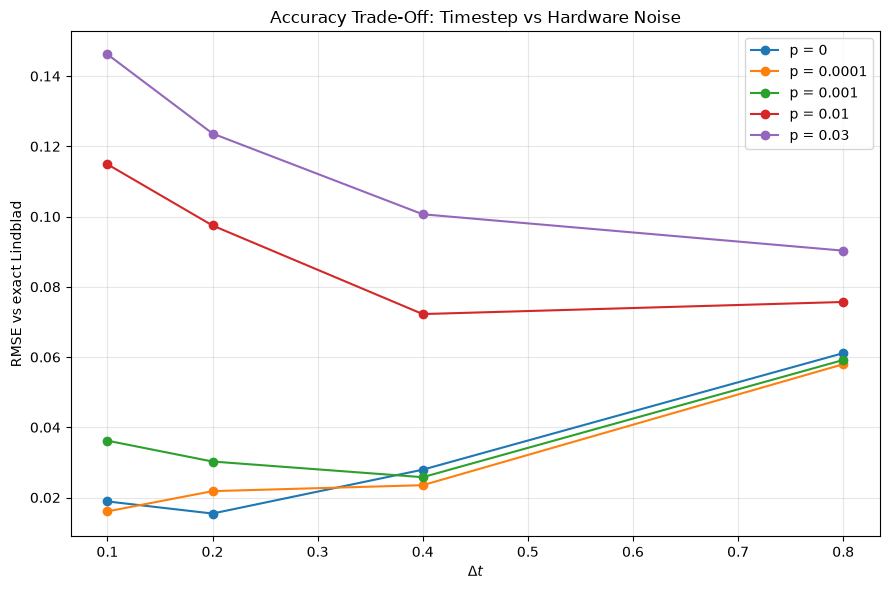

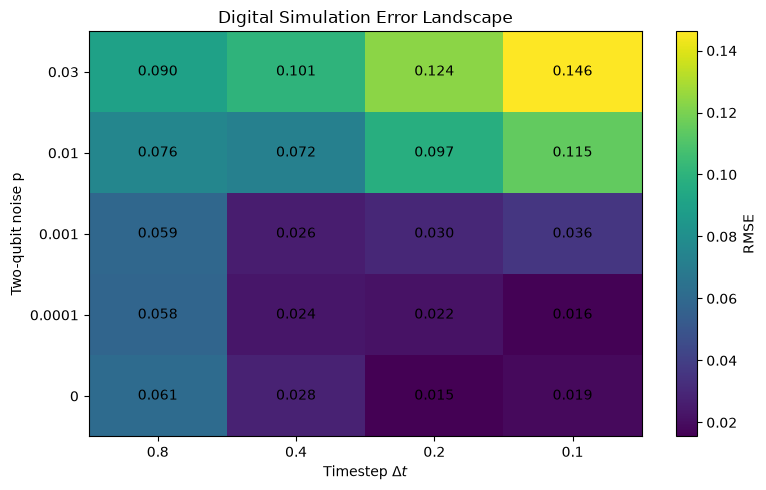


OPTIMAL TIMESTEP AND CIRCUIT COST
---------------------------------
           p     Best dt       Depth    CX gates
------------------------------------------------
           0       0.200        1726         400
      0.0001       0.100        3446         800
       0.001       0.400         866         200
        0.01       0.400         866         200
        0.03       0.800         436         100

SMALLEST vs LARGEST TIMESTEP
----------------------------
           p     RMSE small dt     RMSE large dt
------------------------------------------------
           0          0.018889          0.061110
      0.0001          0.016051          0.057957
       0.001          0.036188          0.059159
        0.01          0.114895          0.075682
        0.03          0.146206          0.090299


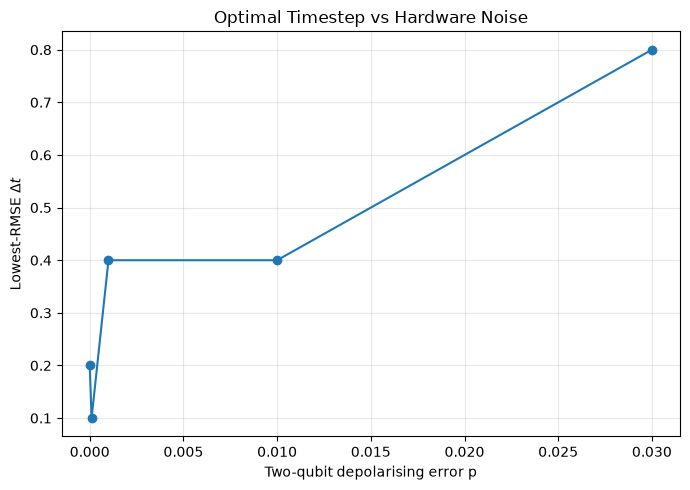


RESEARCH RESULT
---------------
An intermediate timestep gives the lowest RMSE for at least one noisy simulation.
Noise levels with an intermediate optimum:
  p = 0 -> dt = 0.2
  p = 0.001 -> dt = 0.4
  p = 0.01 -> dt = 0.4

NOTEBOOK 06 FINAL SUMMARY
-------------------------
Noiseless best dt : 0.2
Highest-noise best dt : 0.8

Interpretation:
Reducing dt decreases discretisation error, but increases circuit depth and the number of noisy gates.
The preferred timestep therefore depends on the balance between algorithmic error and hardware noise.

Notebook 06 complete.


In [6]:
# Exercise 6.6 — Combined timestep and hardware-noise trade-off

# Uses from Exercises 6.1–6.5:
#
# dt_values
# p_values
# t_max
# gamma
# exact_times
# Mz_exact_dense
# build_circuit()
# magnetisation_from_counts()
# create_depolarising_noise_model()
# resource_results


# ------------------------------------------------------------
# 1. Simulation settings
# ------------------------------------------------------------

dt_tradeoff_values = [
    0.8,
    0.4,
    0.2,
    0.1
]

p_tradeoff_values = [
    0.0,
    1e-4,
    1e-3,
    1e-2,
    3e-2
]

# Lower value keeps the full grid reasonably fast.
# Increase to 4096 or 8192 for your final polished run.
shots_tradeoff = 2048


# ------------------------------------------------------------
# 2. Storage for results
#
# Rows    -> noise p
# Columns -> timestep dt
# ------------------------------------------------------------

rmse_grid = np.zeros(
    (
        len(p_tradeoff_values),
        len(dt_tradeoff_values)
    )
)

final_error_grid = np.zeros_like(
    rmse_grid
)

tradeoff_results = {}


# ------------------------------------------------------------
# 3. Loop over timestep choices
#
# Build and transpile the circuits only once per dt.
# ------------------------------------------------------------

for j, dt_test in enumerate(
    dt_tradeoff_values
):

    print(
        f"\nPreparing dt = {dt_test} ..."
    )


    n_steps = int(
        round(
            t_max / dt_test
        )
    )


    times_test = (
        np.arange(
            n_steps + 1
        )
        * dt_test
    )

    gamma_times_test = (
        gamma
        * times_test
    )


    # Exact Lindblad reference on this time grid
    exact_test = np.interp(
        times_test,
        exact_times,
        Mz_exact_dense
    )


    # Build one circuit for every time point
    circuits_test = [
        build_circuit(
            number_of_steps=n,
            dt_local=dt_test
        )
        for n in range(
            n_steps + 1
        )
    ]


    # Transpile once into the same elementary basis
    compiled_test = transpile(
        circuits_test,
        AerSimulator(),
        basis_gates=[
            "rz",
            "sx",
            "x",
            "cx",
            "reset",
            "measure"
        ],
        optimization_level=1
    )


    # --------------------------------------------------------
    # 4. Run the same circuits at every noise strength
    # --------------------------------------------------------

    for i, p_test in enumerate(
        p_tradeoff_values
    ):

        print(
            f"  Running p = {p_test:g}"
        )


        noise_model = (
            create_depolarising_noise_model(
                p_test
            )
        )


        simulator_test = AerSimulator(
            noise_model=noise_model
        )


        result = simulator_test.run(
            compiled_test,
            shots=shots_tradeoff,
            seed_simulator=12345
        ).result()


        mz_values = []


        for k in range(
            len(compiled_test)
        ):

            counts = result.get_counts(
                k
            )

            mz = magnetisation_from_counts(
                counts,
                shots_tradeoff
            )

            mz_values.append(
                mz
            )


        mz_values = np.array(
            mz_values
        )


        # ----------------------------------------------------
        # 5. Error relative to exact Lindblad dynamics
        # ----------------------------------------------------

        rmse = np.sqrt(
            np.mean(
                (
                    mz_values
                    - exact_test
                )**2
            )
        )


        final_error = abs(
            mz_values[-1]
            - exact_test[-1]
        )


        rmse_grid[
            i,
            j
        ] = rmse


        final_error_grid[
            i,
            j
        ] = final_error


        tradeoff_results[
            (
                p_test,
                dt_test
            )
        ] = {
            "gamma_times":
                gamma_times_test,

            "mz":
                mz_values,

            "exact":
                exact_test,

            "rmse":
                rmse,

            "final_error":
                final_error
        }


print(
    "\nAll timestep-noise simulations complete."
)


# ------------------------------------------------------------
# 6. Print full RMSE table
# ------------------------------------------------------------

print(
    "\nEXERCISE 6.6 — TIMESTEP–NOISE TRADE-OFF"
)

print(
    "----------------------------------------"
)


header = (
    f"{'p \\ dt':>12}"
)

for dt_test in dt_tradeoff_values:

    header += (
        f"{dt_test:>12.3f}"
    )


print(
    header
)

print(
    "-" * (
        12
        + 12 * len(dt_tradeoff_values)
    )
)


for i, p_test in enumerate(
    p_tradeoff_values
):

    row = (
        f"{p_test:>12.5g}"
    )


    for j in range(
        len(dt_tradeoff_values)
    ):

        row += (
            f"{rmse_grid[i, j]:>12.6f}"
        )


    print(
        row
    )


# ------------------------------------------------------------
# 7. Find optimal dt at every noise level
# ------------------------------------------------------------

best_dt_by_noise = {}


print(
    "\nOPTIMAL TIMESTEP FOR EACH NOISE LEVEL"
)

print(
    "-------------------------------------"
)


print(
    f"{'p':>12}"
    f"{'Best dt':>12}"
    f"{'RMSE':>14}"
)

print(
    "-" * 38
)


for i, p_test in enumerate(
    p_tradeoff_values
):

    best_index = np.argmin(
        rmse_grid[
            i,
            :
        ]
    )


    best_dt = (
        dt_tradeoff_values[
            best_index
        ]
    )


    best_rmse = (
        rmse_grid[
            i,
            best_index
        ]
    )


    best_dt_by_noise[
        p_test
    ] = best_dt


    print(
        f"{p_test:>12.5g}"
        f"{best_dt:>12.3f}"
        f"{best_rmse:>14.6f}"
    )


# ------------------------------------------------------------
# 8. Plot RMSE vs timestep for each noise level
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


for i, p_test in enumerate(
    p_tradeoff_values
):

    plt.plot(
        dt_tradeoff_values,
        rmse_grid[
            i,
            :
        ],
        marker="o",
        label=f"p = {p_test:g}"
    )


plt.xlabel(
    r"$\Delta t$"
)

plt.ylabel(
    "RMSE vs exact Lindblad"
)

plt.title(
    "Accuracy Trade-Off: Timestep vs Hardware Noise"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 9. Heatmap of RMSE
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)


image = plt.imshow(
    rmse_grid,
    aspect="auto",
    origin="lower"
)


plt.colorbar(
    image,
    label="RMSE"
)


plt.xticks(
    range(
        len(dt_tradeoff_values)
    ),
    dt_tradeoff_values
)


plt.yticks(
    range(
        len(p_tradeoff_values)
    ),
    [
        f"{p:g}"
        for p in p_tradeoff_values
    ]
)


plt.xlabel(
    r"Timestep $\Delta t$"
)

plt.ylabel(
    "Two-qubit noise p"
)

plt.title(
    "Digital Simulation Error Landscape"
)


# Write RMSE values inside each cell
for i in range(
    len(p_tradeoff_values)
):

    for j in range(
        len(dt_tradeoff_values)
    ):

        plt.text(
            j,
            i,
            f"{rmse_grid[i, j]:.3f}",
            ha="center",
            va="center"
        )


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 10. Connect with circuit depth
# ------------------------------------------------------------

print(
    "\nOPTIMAL TIMESTEP AND CIRCUIT COST"
)

print(
    "---------------------------------"
)


print(
    f"{'p':>12}"
    f"{'Best dt':>12}"
    f"{'Depth':>12}"
    f"{'CX gates':>12}"
)

print(
    "-" * 48
)


for p_test in p_tradeoff_values:

    best_dt = (
        best_dt_by_noise[
            p_test
        ]
    )


    depth = (
        resource_results[
            best_dt
        ]["transpiled_depth"]
    )


    cx = (
        resource_results[
            best_dt
        ]["cx_gates"]
    )


    print(
        f"{p_test:>12.5g}"
        f"{best_dt:>12.3f}"
        f"{depth:>12d}"
        f"{cx:>12d}"
    )


# ------------------------------------------------------------
# 11. Compare smallest and largest timestep directly
# ------------------------------------------------------------

dt_small = min(
    dt_tradeoff_values
)

dt_large = max(
    dt_tradeoff_values
)


small_index = (
    dt_tradeoff_values.index(
        dt_small
    )
)

large_index = (
    dt_tradeoff_values.index(
        dt_large
    )
)


print(
    "\nSMALLEST vs LARGEST TIMESTEP"
)

print(
    "----------------------------"
)


print(
    f"{'p':>12}"
    f"{'RMSE small dt':>18}"
    f"{'RMSE large dt':>18}"
)

print(
    "-" * 48
)


for i, p_test in enumerate(
    p_tradeoff_values
):

    print(
        f"{p_test:>12.5g}"
        f"{rmse_grid[i, small_index]:>18.6f}"
        f"{rmse_grid[i, large_index]:>18.6f}"
    )


# ------------------------------------------------------------
# 12. Plot best timestep versus noise
# ------------------------------------------------------------

best_dt_array = np.array(
    [
        best_dt_by_noise[p]
        for p in p_tradeoff_values
    ]
)


plt.figure(
    figsize=(7, 5)
)


plt.plot(
    p_tradeoff_values,
    best_dt_array,
    marker="o"
)


plt.xlabel(
    "Two-qubit depolarising error p"
)

plt.ylabel(
    r"Lowest-RMSE $\Delta t$"
)

plt.title(
    "Optimal Timestep vs Hardware Noise"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 13. Determine whether an intermediate optimum appears
# ------------------------------------------------------------

intermediate_dts = (
    dt_tradeoff_values[
        1:-1
    ]
)


intermediate_optima = [
    p
    for p in p_tradeoff_values
    if best_dt_by_noise[p]
    in intermediate_dts
]


print(
    "\nRESEARCH RESULT"
)

print(
    "---------------"
)


if len(
    intermediate_optima
) > 0:

    print(
        "An intermediate timestep gives the lowest "
        "RMSE for at least one noisy simulation."
    )

    print(
        "Noise levels with an intermediate optimum:"
    )

    for p in intermediate_optima:

        print(
            f"  p = {p:g} "
            f"-> dt = "
            f"{best_dt_by_noise[p]}"
        )

else:

    print(
        "No intermediate optimum was observed over "
        "the tested parameter grid."
    )

    print(
        "This is still a valid result: within this "
        "noise and timestep range, one error source "
        "continues to dominate."
    )


# ------------------------------------------------------------
# 14. Final Notebook 06 summary
# ------------------------------------------------------------

print(
    "\nNOTEBOOK 06 FINAL SUMMARY"
)

print(
    "-------------------------"
)


print(
    "Noiseless best dt :",
    best_dt_by_noise[
        0.0
    ]
)


print(
    "Highest-noise best dt :",
    best_dt_by_noise[
        max(
            p_tradeoff_values
        )
    ]
)


print(
    "\nInterpretation:"
)

print(
    "Reducing dt decreases discretisation error, "
    "but increases circuit depth and the number "
    "of noisy gates."
)

print(
    "The preferred timestep therefore depends on "
    "the balance between algorithmic error and "
    "hardware noise."
)

print(
    "\nNotebook 06 complete."
)

In [ ]:
# Exercise 6.6b — Self-contained high-statistics validation
#
# This cell can be run after a fresh kernel.
# It does NOT rerun Exercises 6.1–6.6.

import numpy as np
import qutip as qt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error
)


# ============================================================
# 1. PHYSICAL PARAMETERS
# ============================================================

J = 1.0
Delta = 1.0
gamma = 0.5

gamma_t_max = 4.0

t_max = (
    gamma_t_max
    / gamma
)

x_fixed = 0.4906


# ============================================================
# 2. QUANTUM OPERATORS
# ============================================================

I = np.eye(
    2,
    dtype=complex
)

X = np.array(
    [
        [0, 1],
        [1, 0]
    ],
    dtype=complex
)

Z = np.array(
    [
        [1, 0],
        [0, -1]
    ],
    dtype=complex
)

# Our convention:
#
# |0> = up/excited
# |1> = down/decayed

sigma_minus = np.array(
    [
        [0, 0],
        [1, 0]
    ],
    dtype=complex
)


X1 = np.kron(
    X,
    I
)

X2 = np.kron(
    I,
    X
)

Z1 = np.kron(
    Z,
    I
)

Z2 = np.kron(
    I,
    Z
)

ZZ = np.kron(
    Z,
    Z
)


H = (
    -J * ZZ
    + Delta * (
        X1 + X2
    )
)


L1 = (
    np.sqrt(gamma)
    * np.kron(
        sigma_minus,
        I
    )
)

L2 = (
    np.sqrt(gamma)
    * np.kron(
        I,
        sigma_minus
    )
)


Mz = (
    Z1 + Z2
) / 2


# Initial state |00> = |up up>

psi0 = np.array(
    [1, 0, 0, 0],
    dtype=complex
)

rho0 = np.outer(
    psi0,
    psi0.conj()
)


# ============================================================
# 3. EXACT LINDBLAD REFERENCE
# ============================================================

H_qt = qt.Qobj(
    H,
    dims=[
        [2, 2],
        [2, 2]
    ]
)

rho0_qt = qt.Qobj(
    rho0,
    dims=[
        [2, 2],
        [2, 2]
    ]
)

Mz_qt = qt.Qobj(
    Mz,
    dims=[
        [2, 2],
        [2, 2]
    ]
)

collapse_ops_qt = [
    qt.Qobj(
        L1,
        dims=[
            [2, 2],
            [2, 2]
        ]
    ),
    qt.Qobj(
        L2,
        dims=[
            [2, 2],
            [2, 2]
        ]
    )
]


exact_times = np.linspace(
    0,
    t_max,
    1001
)


exact_result = qt.mesolve(
    H_qt,
    rho0_qt,
    exact_times,
    collapse_ops_qt,
    e_ops=[
        Mz_qt
    ]
)


Mz_exact_dense = np.real(
    exact_result.expect[0]
)


# ============================================================
# 4. HAMILTONIAN TROTTER STEP
# ============================================================

def append_dti_trotter(
    circuit,
    q0,
    q1,
    tau
):

    theta_x = (
        Delta * tau
    )

    circuit.rx(
        theta_x,
        q0
    )

    circuit.rx(
        theta_x,
        q1
    )


    theta_zz = (
        -2 * J * tau
    )

    circuit.rzz(
        theta_zz,
        q0,
        q1
    )


    circuit.rx(
        theta_x,
        q0
    )

    circuit.rx(
        theta_x,
        q1
    )


# ============================================================
# 5. ANCILLA DECAY CHANNEL
# ============================================================

def append_decay_channel(
    circuit,
    system_qubit,
    ancilla_qubit,
    classical_bit,
    dt_local
):

    theta_decay = (
        2
        * np.arcsin(
            np.sqrt(
                gamma
                * dt_local
            )
        )
    )


    # Control on system = |0>

    circuit.x(
        system_qubit
    )

    circuit.cry(
        theta_decay,
        system_qubit,
        ancilla_qubit
    )

    circuit.x(
        system_qubit
    )


    # Apply decay when ancilla = 1

    circuit.cx(
        ancilla_qubit,
        system_qubit
    )


    circuit.measure(
        ancilla_qubit,
        classical_bit
    )

    circuit.reset(
        ancilla_qubit
    )


# ============================================================
# 6. BUILD REPEATED OPEN-SYSTEM CIRCUIT
# ============================================================

def build_circuit(
    number_of_steps,
    dt_local
):

    qc = QuantumCircuit(
        3,
        3
    )


    for _ in range(
        number_of_steps
    ):

        # Hamiltonian before dissipation

        append_dti_trotter(
            qc,
            0,
            1,
            x_fixed * dt_local
        )


        # Spin 1 decay

        append_decay_channel(
            qc,
            0,
            2,
            0,
            dt_local
        )


        # Spin 2 decay

        append_decay_channel(
            qc,
            1,
            2,
            0,
            dt_local
        )


        # Remaining Hamiltonian evolution

        append_dti_trotter(
            qc,
            0,
            1,
            (
                1 - x_fixed
            ) * dt_local
        )


    # Final system measurements

    qc.measure(
        0,
        1
    )

    qc.measure(
        1,
        2
    )


    return qc


# ============================================================
# 7. MAGNETISATION FROM COUNTS
# ============================================================

def magnetisation_from_counts(
    counts,
    shots
):

    total = 0.0


    for bitstring, count in counts.items():

        bits = bitstring.replace(
            " ",
            ""
        )


        # Classical order:
        #
        # c2 c1 c0

        spin2 = int(
            bits[0]
        )

        spin1 = int(
            bits[1]
        )


        z1 = (
            1
            if spin1 == 0
            else -1
        )

        z2 = (
            1
            if spin2 == 0
            else -1
        )


        mz = (
            z1 + z2
        ) / 2


        total += (
            mz
            * count
        )


    return (
        total / shots
    )


# ============================================================
# 8. PAPER-STYLE DEPOLARISING NOISE
# ============================================================

def create_depolarising_noise_model(
    p_two
):

    noise_model = NoiseModel()


    if p_two == 0:

        return noise_model


    p_one = (
        p_two / 10
    )


    error_1q = depolarizing_error(
        p_one,
        1
    )

    error_2q = depolarizing_error(
        p_two,
        2
    )


    noise_model.add_all_qubit_quantum_error(
        error_1q,
        [
            "x",
            "sx",
            "rz"
        ]
    )


    noise_model.add_all_qubit_quantum_error(
        error_2q,
        [
            "cx"
        ]
    )


    return noise_model


# ============================================================
# 9. HIGH-STATISTICS VALIDATION SETTINGS
# ============================================================

dt_check_values = [
    0.1,
    0.2
]

p_check_values = [
    0.0,
    1e-4
]


shots_check = 8192


seeds = [
    101,
    202,
    303,
    404,
    505
]


validation_results = {}


# ============================================================
# 10. RUN ONLY THE FOUR CASES WE CARE ABOUT
# ============================================================

for dt_test in dt_check_values:

    print(
        f"\nPreparing dt = {dt_test} ..."
    )


    n_steps = int(
        round(
            t_max
            / dt_test
        )
    )


    times_test = (
        np.arange(
            n_steps + 1
        )
        * dt_test
    )


    exact_test = np.interp(
        times_test,
        exact_times,
        Mz_exact_dense
    )


    # Build circuits once for this timestep

    circuits_test = [
        build_circuit(
            number_of_steps=n,
            dt_local=dt_test
        )
        for n in range(
            n_steps + 1
        )
    ]


    compiled_test = transpile(
        circuits_test,
        AerSimulator(),
        basis_gates=[
            "rz",
            "sx",
            "x",
            "cx",
            "reset",
            "measure"
        ],
        optimization_level=1
    )


    for p_test in p_check_values:

        print(
            f"  Testing p = {p_test:g}"
        )


        rmse_runs = []


        for seed in seeds:

            noise_model = (
                create_depolarising_noise_model(
                    p_test
                )
            )


            simulator = AerSimulator(
                noise_model=noise_model
            )


            result = simulator.run(
                compiled_test,
                shots=shots_check,
                seed_simulator=seed
            ).result()


            mz_values = []


            for k in range(
                len(compiled_test)
            ):

                counts = result.get_counts(
                    k
                )


                mz = magnetisation_from_counts(
                    counts,
                    shots_check
                )


                mz_values.append(
                    mz
                )


            mz_values = np.array(
                mz_values
            )


            rmse = np.sqrt(
                np.mean(
                    (
                        mz_values
                        - exact_test
                    )**2
                )
            )


            rmse_runs.append(
                rmse
            )


        rmse_runs = np.array(
            rmse_runs
        )


        mean_rmse = np.mean(
            rmse_runs
        )

        std_rmse = np.std(
            rmse_runs,
            ddof=1
        )


        validation_results[
            (
                p_test,
                dt_test
            )
        ] = {
            "mean_rmse":
                mean_rmse,

            "std_rmse":
                std_rmse,

            "all_runs":
                rmse_runs
        }


# ============================================================
# 11. FINAL RESULTS
# ============================================================

print(
    "\nHIGH-STATISTICS VALIDATION"
)

print(
    "--------------------------"
)


print(
    f"{'p':>10}"
    f"{'dt':>10}"
    f"{'Mean RMSE':>16}"
    f"{'Std':>14}"
)

print(
    "-" * 50
)


for p_test in p_check_values:

    for dt_test in dt_check_values:

        result = validation_results[
            (
                p_test,
                dt_test
            )
        ]


        print(
            f"{p_test:>10.5g}"
            f"{dt_test:>10.3f}"
            f"{result['mean_rmse']:>16.6f}"
            f"{result['std_rmse']:>14.6f}"
        )


# ============================================================
# 12. PREFERRED TIMESTEP
# ============================================================

print(
    "\nPREFERRED TIMESTEP"
)

print(
    "------------------"
)


for p_test in p_check_values:

    best_dt = min(
        dt_check_values,
        key=lambda dt:
            validation_results[
                (
                    p_test,
                    dt
                )
            ]["mean_rmse"]
    )


    best = validation_results[
        (
            p_test,
            best_dt
        )
    ]


    print(
        f"p = {p_test:g}: "
        f"best dt = {best_dt}, "
        f"mean RMSE = "
        f"{best['mean_rmse']:.6f} "
        f"± {best['std_rmse']:.6f}"
    )


Preparing dt = 0.1 ...


c:\Users\HP\OneDrive\Documents\coding_project\kim-open-quantum-reproduction\.venv\Lib\site-packages\qiskit\transpiler\preset_passmanagers\generate_preset_pass_manager.py:242: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  common_options = _parse_common_options(


  Testing p = 0
  Testing p = 0.0001
